# Gene Trend Visualization Along Mesenchymal Axis

This notebook visualizes individual gene expression trends along the basalis → luminal axis,
stratified by menstrual phase. Expression fitted values are derived from the GLM fitting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import UnivariateSpline
from scipy.stats import linregress
import warnings
from math import ceil
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100
plt.rcParams['pdf.fonttype'] = 42


## 1. Load Data

In [2]:
# Load results and metadata
pb_meta = pd.read_csv("mesenchymal_pb_meta_tacco_ensemble.tsv", sep="\t")
pb_matrix = pd.read_csv("mesenchymal_pb_matrix_tacco_ensemble.tsv", sep="\t", index_col=0)

print(f"\nMetadata shape: {pb_meta.shape}")
print(f"Count matrix shape: {pb_matrix.shape}")


Metadata shape: (480, 6)
Count matrix shape: (35103, 480)


In [3]:
# Drop bins with fewer than 10 cells
n_before = len(pb_meta)
pb_meta = pb_meta[pb_meta['n_cells'] >= 10].reset_index(drop=True)
pb_matrix = pb_matrix[pb_meta['sample'] + '_' + pb_meta['axis_bin'].astype(str)]
print(f"Dropped {n_before - len(pb_meta)} bins with < 10 cells ({len(pb_meta)} remaining)")

Dropped 0 bins with < 10 cells (480 remaining)


In [4]:
pb_meta.head()

,sample,axis_bin,axis_bin_mid,menstrual_phase,n_cells,donor_n_bins
0,A13,basalis_1,0.083333,Proliferative,1397,6
1,A13,basalis_2,0.250000,Proliferative,4264,6
2,A13,functionalis_1,0.416667,Proliferative,4640,6
3,A13,functionalis_2,0.583333,Proliferative,3364,6
4,A13,functionalis_3,0.750000,Proliferative,1310,6


In [5]:
pb_meta[
    pb_meta['menstrual_phase'] == 'Menstrual'
]['sample'].value_counts()

sample
BZ14-END-0-FTM-1 (Control9)    5
E01                            5
FX1341                         3
Name: count, dtype: int64

## 2. Prepare Data for Visualization

In [6]:
# Normalize counts to CPM (counts per million)
lib_sizes = pb_matrix.sum(axis=0).values
cpm_matrix = (pb_matrix / lib_sizes * 1e6)
log2_cpm_matrix = np.log2(cpm_matrix + 1)  # Add pseudocount

# Menstrual phase colors
phase_colors = {
    'Proliferative': 'forestgreen',
    'Secretory': 'yellowgreen',
    'Menstrual': 'darkorange',
    # 'Hormones': 'turquoise'
}


# Phase order
phase_order = ['Proliferative', 'Secretory', 'Menstrual',] # 'Hormones']

# Categorical axis_bin order
axis_bin_order = ['basalis_1', 'basalis_2', 'functionalis_1', 'functionalis_2', 'functionalis_3', 'lumen_1']

# Sort metadata by categorical axis_bin order
pb_meta['axis_bin'] = pd.Categorical(pb_meta['axis_bin'], categories=axis_bin_order, ordered=True)
pb_meta = pb_meta.sort_values('axis_bin').reset_index(drop=True)

# Reorder expression matrices to match sorted metadata
meta_col_names = pb_meta['sample'] + '_' + pb_meta['axis_bin'].astype(str)
cpm_matrix = cpm_matrix[meta_col_names]
log2_cpm_matrix = log2_cpm_matrix[meta_col_names]

print(f"CPM matrix shape: {cpm_matrix.shape}")
print(f"\nAxis bin order: {pb_meta['axis_bin'].unique().tolist()}")
print(f"Column names aligned: {all(meta_col_names == cpm_matrix.columns)}")

CPM matrix shape: (35103, 480)

Axis bin order: ['basalis_1', 'basalis_2', 'functionalis_1', 'functionalis_2', 'functionalis_3', 'lumen_1']
Column names aligned: True


In [7]:
# ## Donor filter
# # Set selected_donors to a list of donor IDs to restrict plots to those donors.
# # Set to None (or leave as an empty list) to use all donors.

# print("Available donors:")
# for d in sorted(pb_meta['sample'].unique()):
#     phase = pb_meta.loc[pb_meta['sample'] == d, 'menstrual_phase'].iloc[0]
#     print(f"  {d!r}  ({phase})")

## 3. Define Plotting Function

In [8]:
ft_samples = ['A13', 'A14', 'A16', 'A17', 'A22', 'D1', 'D2', 'D3', 'D4', 'D5', 'D7']

axis_bin_order = [
    'basalis_1', 'basalis_2',
    'functionalis_1', 'functionalis_2', 'functionalis_3',
    'lumen_1'
]

def plot_gene_trend(gene_name, pb_meta, log2_cpm_matrix,
                    phase_colors, phase_order, n_grid=100, smooth_factor=0.5,
                    k=2, ncols=3, filter_to_full_thickness=False,
                    add_ci=False, ci=95, n_boot=500, random_state=0, stages=None,
                    drop_zero_donor=False, save = None):
    
    # ── optionally filter stages ────────────────────────

    if stages is not None:
        stages_mask = pb_meta['menstrual_phase'].isin(stages)
        pb_meta = pb_meta[stages_mask].reset_index(drop=True)
        st_cols = pb_meta['sample'] + '_' + pb_meta['axis_bin'].astype(str)
        log2_cpm_matrix = log2_cpm_matrix[st_cols]
    

    # ── optionally restrict to full-thickness donors ────────────────────────
    if filter_to_full_thickness:
        ft_mask = pb_meta['sample'].isin(ft_samples)
        pb_meta = pb_meta[ft_mask].reset_index(drop=True)
        ft_cols = pb_meta['sample'] + '_' + pb_meta['axis_bin'].astype(str)
        log2_cpm_matrix = log2_cpm_matrix[ft_cols]

    # ── build numeric encoding for categorical axis_bin ─────────────────────
    present_bins = [b for b in axis_bin_order if b in pb_meta['axis_bin'].values]
    bin_to_int = {b: i for i, b in enumerate(present_bins)}

    pb_meta = pb_meta.copy()
    pb_meta['axis_bin_int'] = pb_meta['axis_bin'].map(bin_to_int)

    axis_int_min = 0
    axis_int_max = len(present_bins) - 1
    axis_grid_int = np.linspace(axis_int_min, axis_int_max, n_grid)

    tick_positions = list(range(len(present_bins)))
    tick_labels = present_bins

    rng = np.random.default_rng(random_state)

    # ── helper that draws a single gene onto a given Axes ───────────────────
    def _plot_single(gene, ax):
        if gene not in log2_cpm_matrix.index:
            ax.text(
                0.5, 0.5, f"'{gene}'\nnot found",
                ha='center', va='center',
                transform=ax.transAxes,
                color='red'
            )
            ax.set_title(gene)
            return

        expr = log2_cpm_matrix.loc[gene].values

        for phase in phase_order:
            phase_mask = pb_meta['menstrual_phase'] == phase
            phase_indices = np.where(phase_mask.values)[0]

            if len(phase_indices) == 0:
                continue

            phase_axis_int = pb_meta.loc[phase_mask, 'axis_bin_int'].values
            phase_expr = expr[phase_indices]

            # ── optionally drop donors whose expression is all zero ──────────
            if drop_zero_donor:
                import pandas as _pd
                phase_donors = pb_meta.loc[phase_mask, 'sample'].values
                donor_max = _pd.Series(phase_expr, index=phase_donors).groupby(level=0).max()
                keep_donors = donor_max[donor_max > 0].index
                keep_mask = _pd.Series(phase_donors).isin(keep_donors).values
                phase_axis_int = phase_axis_int[keep_mask]
                phase_expr = phase_expr[keep_mask]
                if len(phase_expr) == 0:
                    continue

            ax.scatter(
                phase_axis_int,
                phase_expr,
                color=phase_colors[phase],
                s=8,
                alpha=0.75,
                label=phase,
                edgecolor='black',
                linewidth=0.5
            )

            import pandas as _pd

            bin_means = (
                _pd.Series(phase_expr, index=phase_axis_int)
                .groupby(level=0)
                .mean()
                .dropna()
                .sort_index()
            )

            x_fit = bin_means.index.values.astype(float)
            y_fit = bin_means.values

            if len(x_fit) > 3:
                try:
                    spline = UnivariateSpline(
                        x_fit,
                        y_fit,
                        s=smooth_factor * len(x_fit),
                        k=min(k, len(x_fit) - 1)
                    )

                    smooth_expr = spline(axis_grid_int)

                    ax.plot(
                        axis_grid_int,
                        smooth_expr,
                        color=phase_colors[phase],
                        linewidth=2.5,
                        linestyle='-'
                    )

                    # ── optional bootstrapped CI around spline ───────────────
                    if add_ci:
                        phase_df = _pd.DataFrame({
                            "x": phase_axis_int.astype(float),
                            "y": phase_expr
                        })

                        boot_curves = []

                        for _ in range(n_boot):
                            boot_idx = rng.integers(
                                0,
                                len(phase_df),
                                size=len(phase_df)
                            )
                            boot_df = phase_df.iloc[boot_idx]

                            boot_means = (
                                boot_df
                                .groupby("x")["y"]
                                .mean()
                                .dropna()
                                .sort_index()
                            )

                            x_boot = boot_means.index.values.astype(float)
                            y_boot = boot_means.values

                            if len(x_boot) > k:
                                try:
                                    boot_spline = UnivariateSpline(
                                        x_boot,
                                        y_boot,
                                        s=smooth_factor * len(x_boot),
                                        k=min(k, len(x_boot) - 1)
                                    )

                                    boot_curves.append(
                                        boot_spline(axis_grid_int)
                                    )
                                except Exception:
                                    pass

                        if len(boot_curves) > 10:
                            boot_curves = np.vstack(boot_curves)

                            alpha = (100 - ci) / 2
                            lower = np.nanpercentile(
                                boot_curves,
                                alpha,
                                axis=0
                            )
                            upper = np.nanpercentile(
                                boot_curves,
                                100 - alpha,
                                axis=0
                            )

                            ax.fill_between(
                                axis_grid_int,
                                lower,
                                upper,
                                color=phase_colors[phase],
                                alpha=0.18,
                                linewidth=0
                            )

                except Exception:
                    try:
                        slope, intercept, _, _, _ = linregress(x_fit, y_fit)

                        ax.plot(
                            axis_grid_int,
                            slope * axis_grid_int + intercept,
                            color=phase_colors[phase],
                            linewidth=2.5,
                            linestyle='--'
                        )
                    except Exception:
                        pass

        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=35, ha='right', fontsize=9)
        ax.set_xlabel('Basalis → Luminal Axis')
        ax.set_ylabel('log2-CPM')
        ax.set_title(gene, fontsize=12)
        ax.legend(loc='best', frameon=True, fontsize=10)
        ax.grid(True, alpha=0.2)

    # ── single-gene path ────────────────────────────────────────────────────
    if isinstance(gene_name, str):
        fig, ax = plt.subplots(figsize=(6, 4))
        _plot_single(gene_name, ax)
        plt.tight_layout()
        return fig

    # ── multi-gene grid path ────────────────────────────────────────────────
    genes = list(gene_name)
    n = len(genes)
    ncols = min(ncols, n)
    nrows = ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4 * ncols, 4 * nrows),
        squeeze=False
    )

    for i, gene in enumerate(genes):
        row, col = divmod(i, ncols)
        _plot_single(gene, axes[row][col])

    for j in range(n, nrows * ncols):
        row, col = divmod(j, ncols)
        axes[row][col].set_visible(False)

    plt.tight_layout()

    if save:
        plt.savefig(save)
    
    return fig

In [9]:
genes = ['HAS2', 'CEMIP', 'HSD11B1', 'HSD11B2', 'OGN', 'ANGPT2', 'ANGPT1']

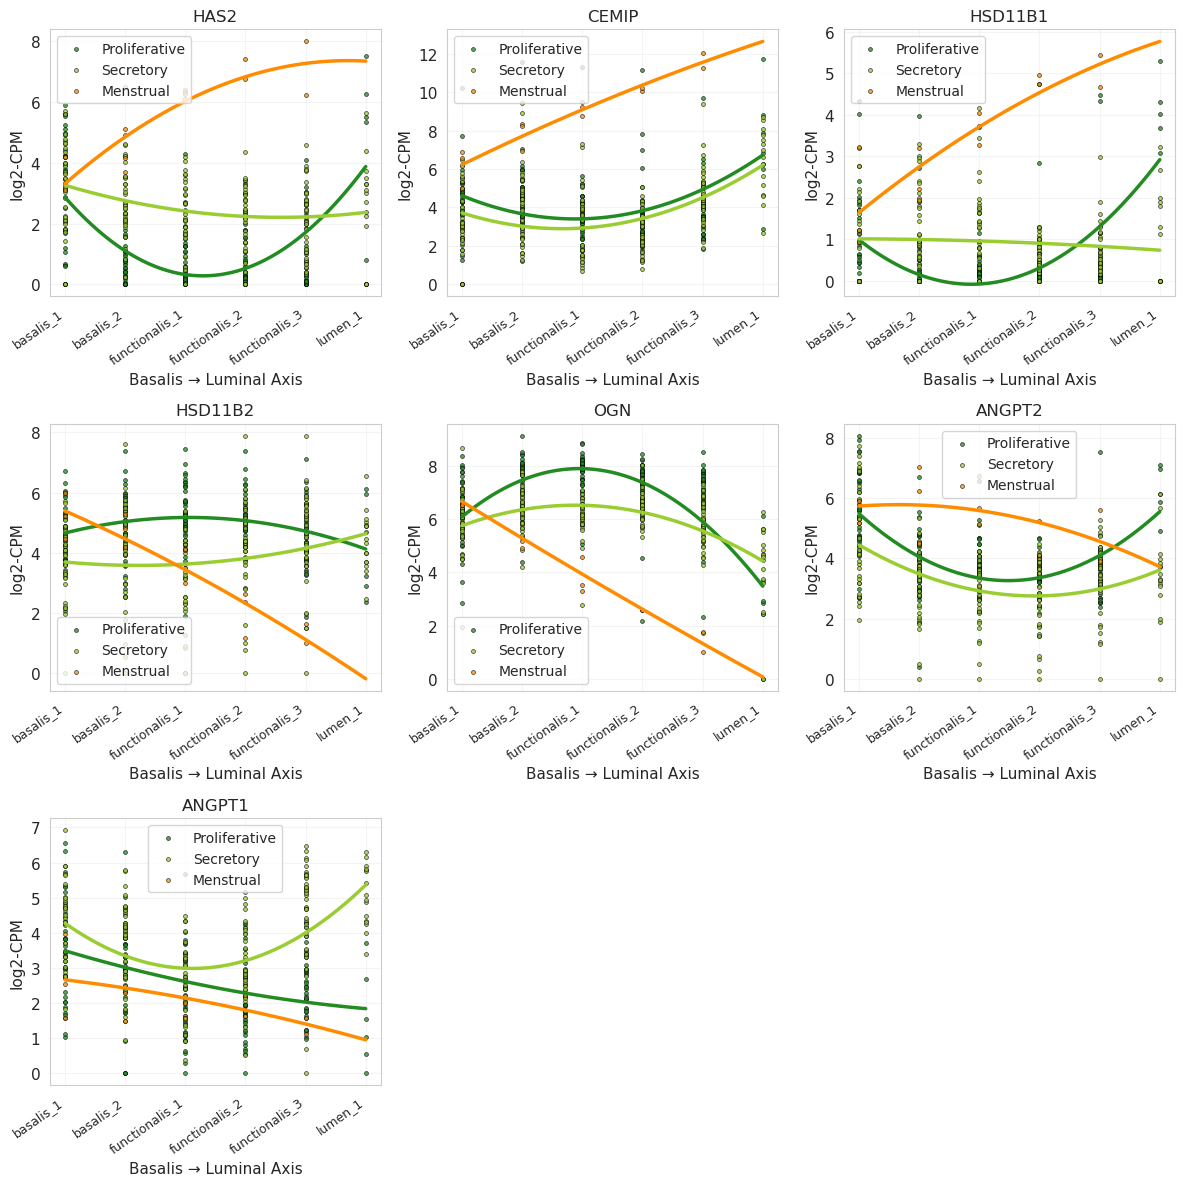

In [10]:
plot_gene_trend(genes, pb_meta, log2_cpm_matrix, phase_colors, phase_order)
plt.show()

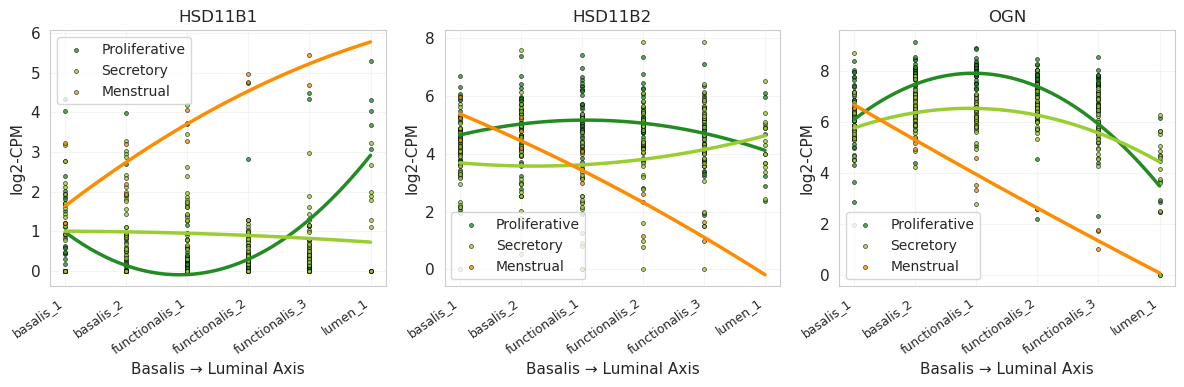

In [11]:
plot_gene_trend(['HSD11B1', 'HSD11B2', 'OGN'], pb_meta, log2_cpm_matrix, phase_colors, phase_order)
plt.savefig('hsd11b_ogn.pdf')
plt.show()

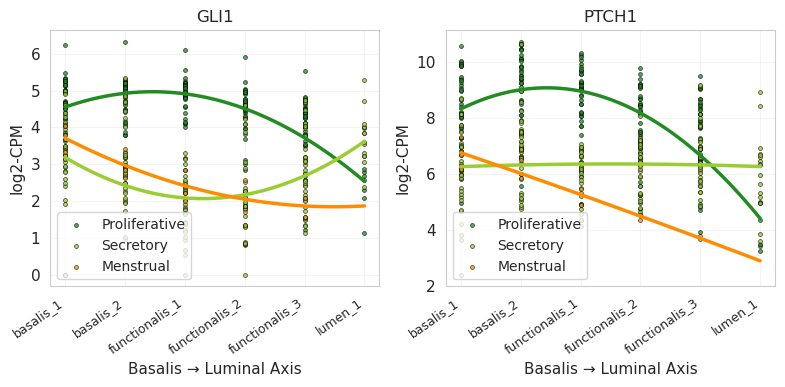

In [12]:
plot_gene_trend(['GLI1', 'PTCH1'], 
                pb_meta, log2_cpm_matrix, 
                phase_colors, phase_order, stages = ['Menstrual', 'Proliferative', 'Secretory'], save = 'sfrp5_xenium.pdf')
plt.show()

In [14]:
cytokines = [g for g in log2_cpm_matrix.index if g.startswith('CXCL') | g.startswith('CCL')]

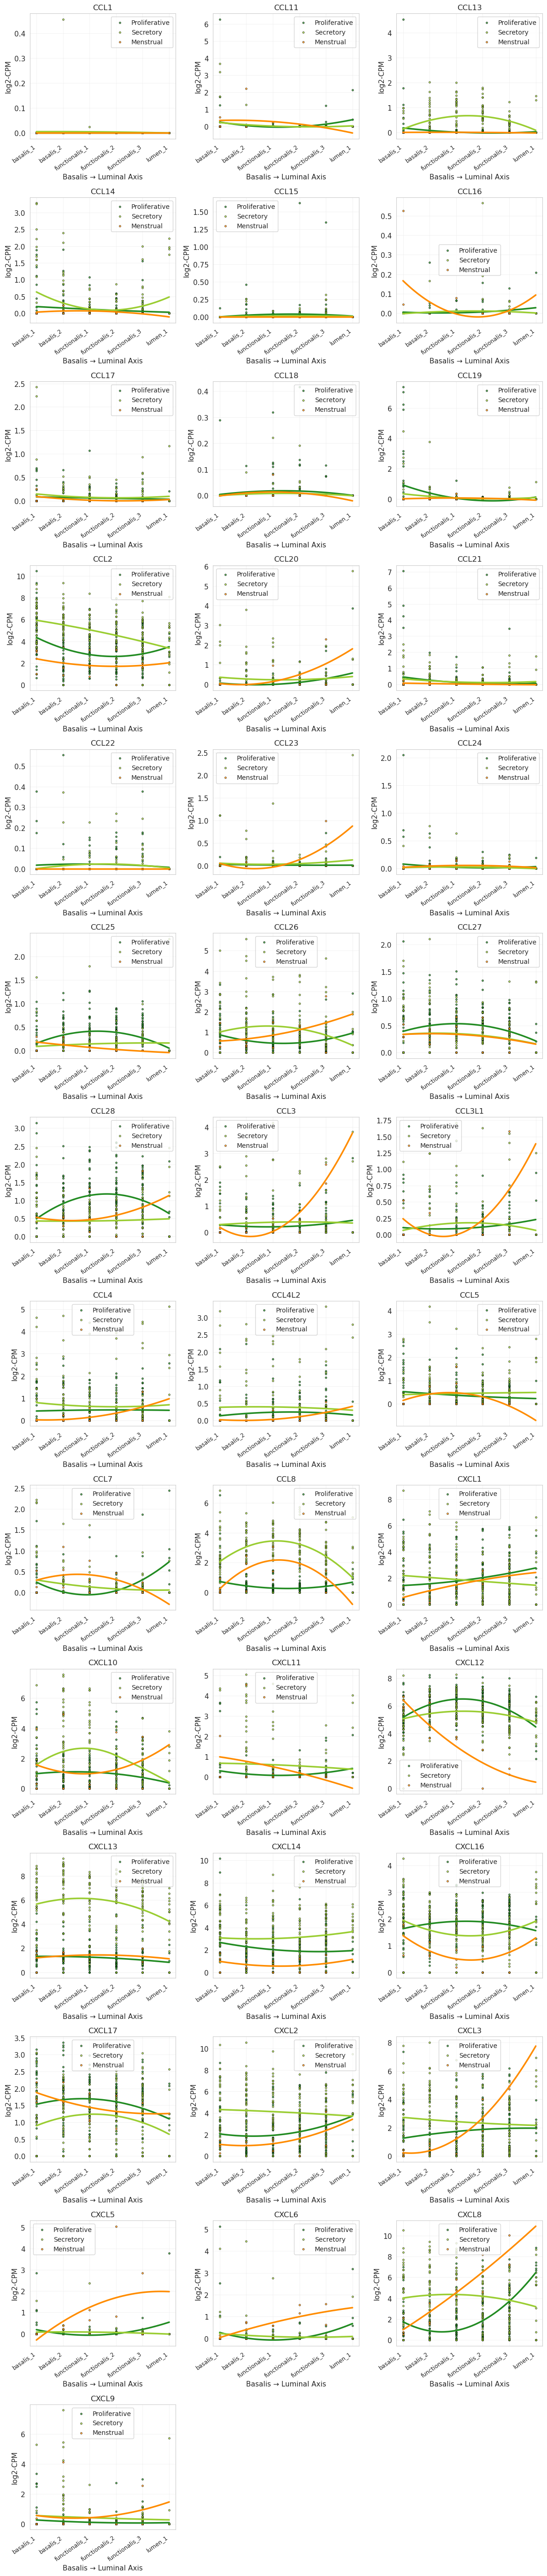

In [16]:
plot_gene_trend(cytokines, pb_meta, log2_cpm_matrix, phase_colors, phase_order)
plt.show()

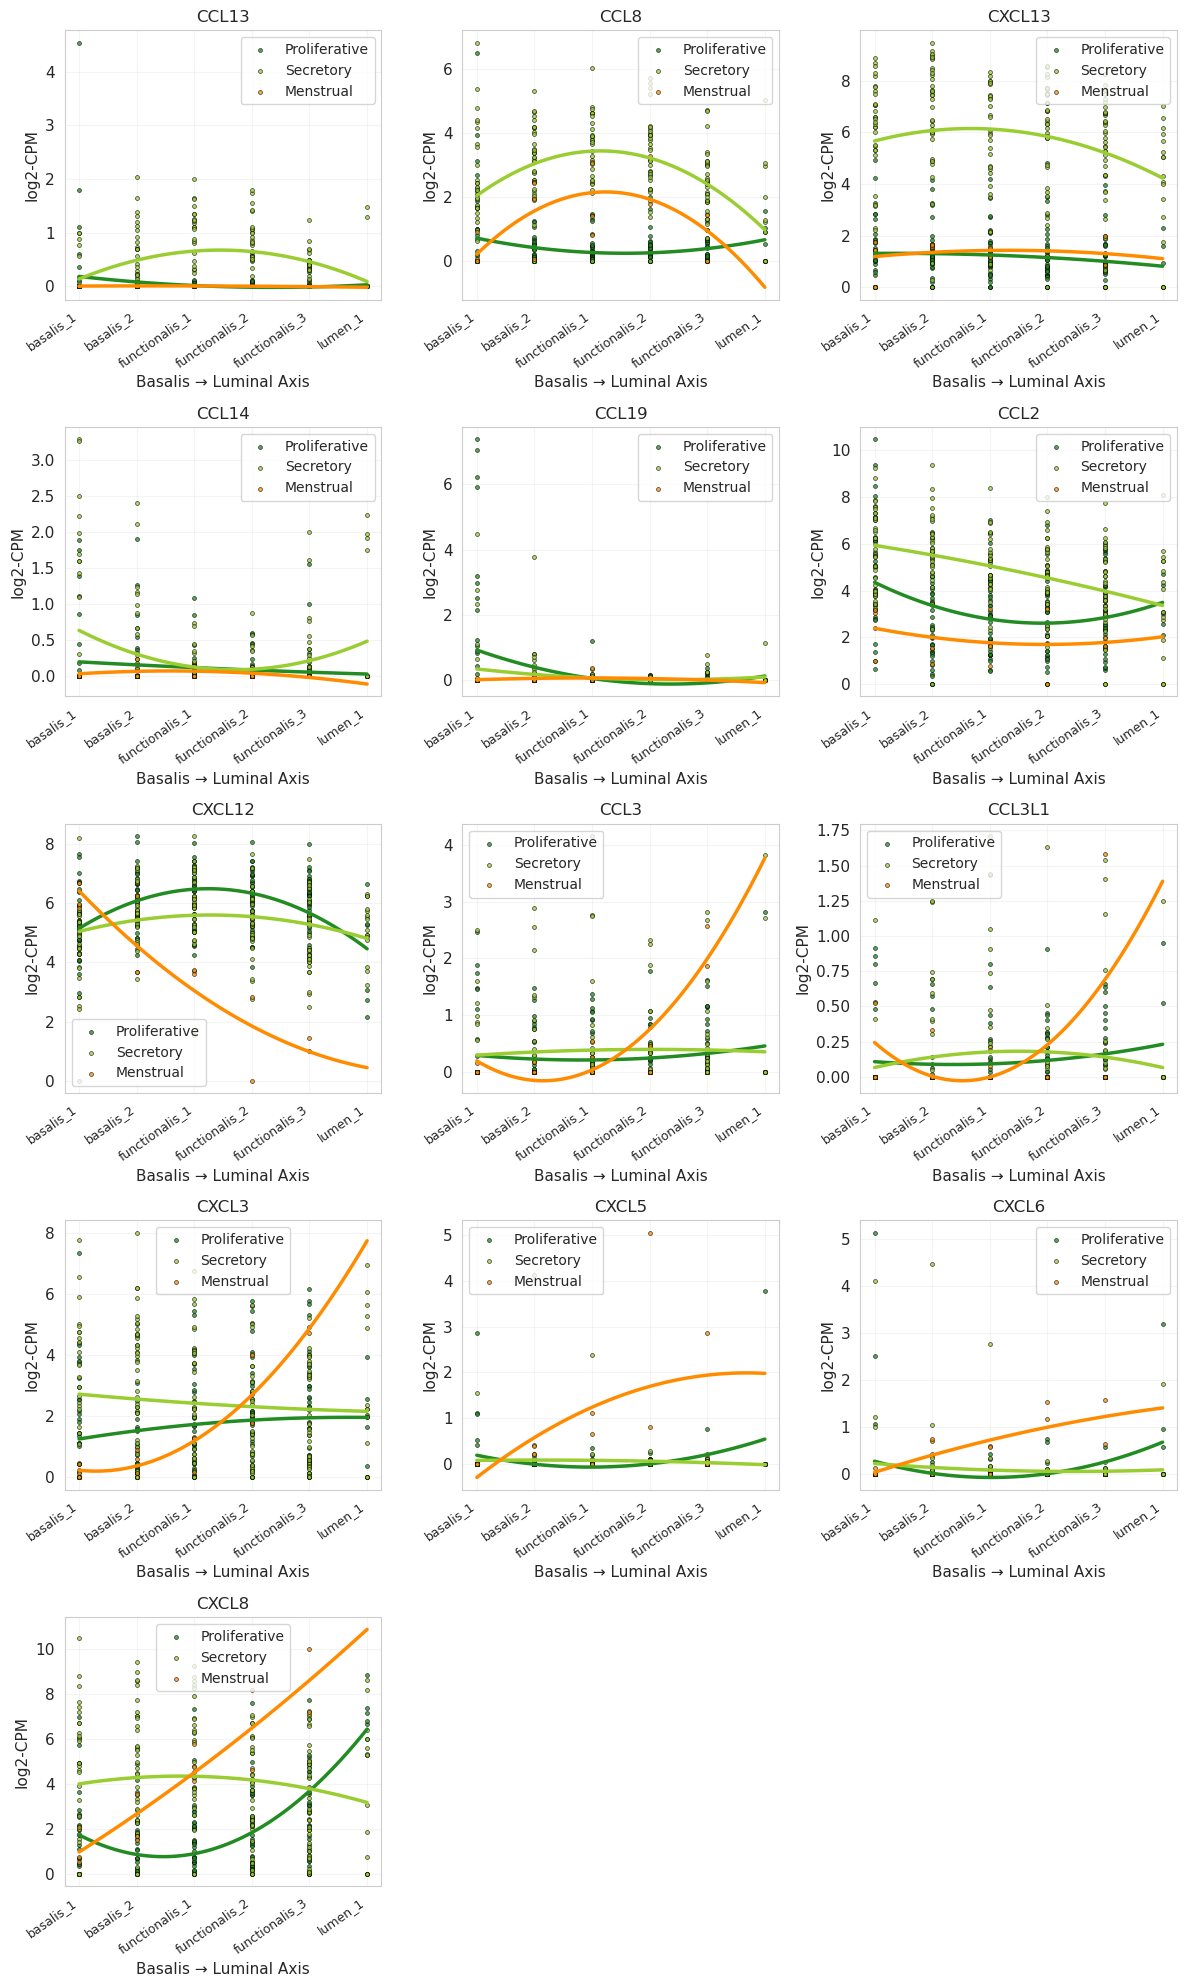

In [17]:
cytokines = [
    'CCL13', 'CCL8', 'CXCL13', 'CCL14', 'CCL19', 
    'CCL2', 'CXCL12', 'CCL3', 'CCL3L1', 'CXCL3', 'CXCL5', 'CXCL6', 'CXCL8'
]

plot_gene_trend(cytokines, pb_meta, log2_cpm_matrix, phase_colors, phase_order)
plt.show()

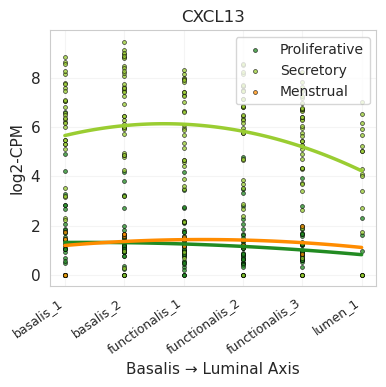

In [9]:
plot_gene_trend(['CXCL13'], pb_meta, log2_cpm_matrix, phase_colors, phase_order)
plt.show()

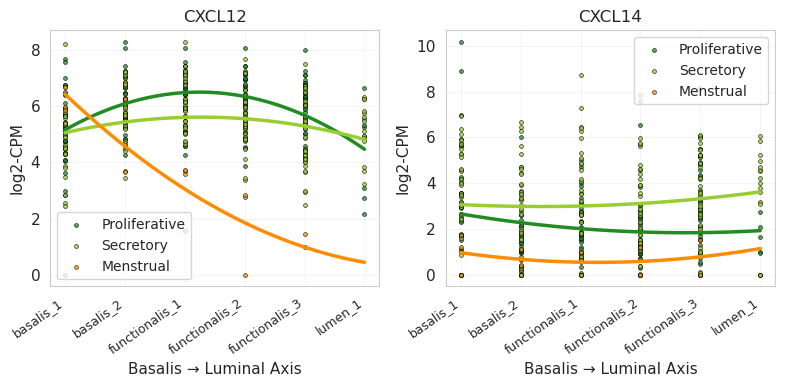

In [10]:
plot_gene_trend(['CXCL12', 'CXCL14'], pb_meta, log2_cpm_matrix, phase_colors, phase_order)
plt.show()